# Random Walk Multidimensional — Notebook (Formato A)

**Instruções:** este notebook segue o padrão **Markdown → Python → Markdown → Python → ...**.  
Em cada célula de código você pode **definir `dim`** (1, 2, 3, ...). As células Markdown explicam a teoria ou o objetivo da célula de código seguinte.

---

**Parâmetros principais (defina na célula de código):**

- `dim` : dimensão do espaço (1, 2, 3, ...)
- `n_passos` : número de passos por caminhada
- `n_caminhadas` : número de caminhadas independentes

---

**Observação:** use $$ ... $$ para fórmulas em bloco e $ ... $ para fórmulas inline.

In [5]:
# Parâmetros (edite aqui)
dim = 2           # escolha a dimensão: 1, 2, 3, ...
n_passos = 10000  # passos por caminhada
n_caminhadas = 10 # número de caminhadas

# Funções utilitárias
import random
import math

def random_walker(dim=1, n_passos=1000):
    """Gera um trajeto de um random walk em 'dim' dimensões."""
    pos = [0] * dim
    trajeto = [pos.copy()]
    for _ in range(n_passos):
        eixo = random.randint(0, dim - 1)
        direcao = random.choice([-1, 1])
        pos[eixo] += direcao
        trajeto.append(pos.copy())
    return trajeto

def distancia_euclidiana(pos):
    """Distância euclidiana da origem para uma posição (lista)."""
    return math.sqrt(sum(c*c for c in pos))

print(f"Parâmetros: dim={dim}, n_passos={n_passos}, n_caminhadas={n_caminhadas}")

Parâmetros: dim=2, n_passos=10000, n_caminhadas=10


## Teoria 1D (fórmula exata)

Para o random walk simples em 1D, com passos $+1$ ou $-1$ equiprováveis:

$$
S_n = \sum_{i=1}^{n} X_i, \quad X_i \in \{-1,+1\}, \quad P(X_i=1)=P(X_i=-1)=\tfrac{1}{2}.
$$

A probabilidade de deslocamento final $d$ após $n$ passos é:

$$
P_n(d) = \frac{1}{2^n}\binom{n}{\frac{n+d}{2}}.
$$

Válida quando $n+d$ é par e $|d|\le n$; caso contrário $P_n(d)=0$.

In [6]:
# Função teórica P1D
def P1D(n, d):
    """Probabilidade exata do deslocamento d após n passos em 1D."""
    if (n + d) % 2 != 0 or abs(d) > n:
        return 0.0
    k = (n + d) // 2
    return math.comb(n, k) / (2 ** n)

# Simulação empírica (apenas faz sentido para dim == 1)
def simular_empirica_1D(n_passos, n_caminhadas):
    finais = []
    for _ in range(n_caminhadas):
        traj = random_walker(dim=1, n_passos=n_passos)
        finais.append(traj[-1][0])
    return finais

# Exemplo de uso condicional
if dim == 1:
    finais = simular_empirica_1D(n_passos, n_caminhadas)
    from collections import Counter
    freq = Counter(finais)
    print("Frequências empíricas (amostra):", dict(freq))
    for d in sorted(freq.keys()):
        print(f"d={d}: empírico={freq[d]/n_caminhadas:.4f}, teórico={P1D(n_passos, d):.6e}")
else:
    print("dim != 1 — pule esta célula ou defina dim = 1 para executar P1D.")

dim != 1 — pule esta célula ou defina dim = 1 para executar P1D.


## Random Walk em 2D usando resultados 1D

No modelo discreto clássico em 2D, as coordenadas $X_n$ e $Y_n$ são independentes e cada uma segue um random walk 1D.  
Assim, a probabilidade de terminar em $(x,y)$ após $n$ passos é:

$$
P((X_n,Y_n)=(x,y)) = P_n(x)\, P_n(y),
$$

onde cada $P_n(\cdot)$ é a fórmula 1D mostrada anteriormente.

In [7]:
def P2D(n, x, y):
    """Probabilidade teórica em 2D como produto de duas 1D (eixos independentes)."""
    return P1D(n, x) * P1D(n, y)

def simular_empirica_2D(n_passos, n_caminhadas):
    finais = []
    for _ in range(n_caminhadas):
        traj = random_walker(dim=2, n_passos=n_passos)
        finais.append(tuple(traj[-1]))  # (x,y)
    return finais

# Exemplo condicional para dim == 2
if dim == 2:
    finais = simular_empirica_2D(n_passos, n_caminhadas)
    from collections import Counter
    freq = Counter(finais)
    print("Exemplo de posições finais (amostra):", list(freq.items())[:10])
    exemplo = finais[0]
    x,y = exemplo
    print(f"Exemplo ponto {exemplo}: empírico={freq[exemplo]/n_caminhadas:.4f}, teórico={P2D(n_passos, x, y):.6e}")
else:
    print("dim != 2 — pule esta célula ou defina dim = 2 para executar P2D.")

Exemplo de posições finais (amostra): [((-39, -45), 1), ((-52, -24), 1), ((-172, 28), 1), ((170, -2), 1), ((105, -127), 1), ((20, 24), 1), ((12, -10), 1), ((57, 63), 1), ((-80, -66), 1), ((26, -126), 1)]
Exemplo ponto (-39, -45): empírico=0.1000, teórico=0.000000e+00


## Visualização e análise

- Para **1D**: plotar histograma das posições finais e comparar com $P_n(d)$.  
- Para **2D**: plotar scatter das posições finais; comparar densidade empírica com produto das 1D.  
- Para **dim >= 3**: analisar estatísticas como distância média da origem, variância, RMS.

A célula de código seguinte faz visualizações condicionais conforme `dim`.

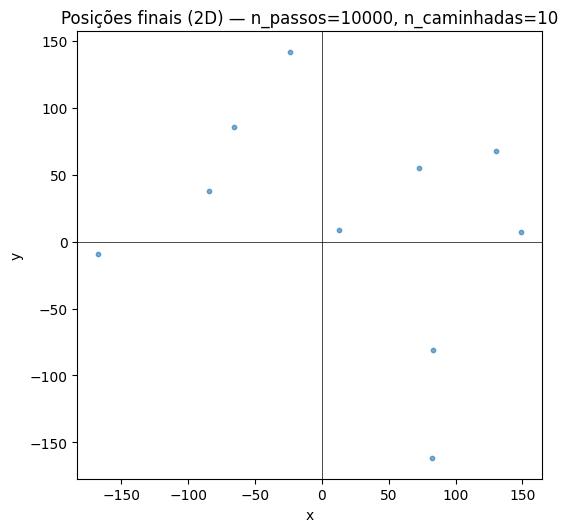

In [8]:
# Visualização condicional (requer matplotlib)
import matplotlib.pyplot as plt
plt.style.use('default')

if dim == 1:
    finais = simular_empirica_1D(n_passos, n_caminhadas)
    plt.figure(figsize=(8,4))
    plt.hist(finais, bins=range(min(finais)-1, max(finais)+2), density=True, alpha=0.6, label='empírico')
    xs = range(min(finais), max(finais)+1)
    ys = [P1D(n_passos, x) for x in xs]
    plt.plot(xs, ys, 'o-', label='teórico P1D')
    plt.xlabel('posição final d')
    plt.ylabel('probabilidade')
    plt.legend()
    plt.title(f'Histograma posições finais (1D) — n_passos={n_passos}, n_caminhadas={n_caminhadas}')
    plt.show()

elif dim == 2:
    finais = simular_empirica_2D(n_passos, n_caminhadas)
    xs = [p[0] for p in finais]
    ys = [p[1] for p in finais]
    plt.figure(figsize=(6,6))
    plt.scatter(xs, ys, s=10, alpha=0.6)
    plt.xlabel('x'); plt.ylabel('y')
    plt.title(f'Posições finais (2D) — n_passos={n_passos}, n_caminhadas={n_caminhadas}')
    plt.axhline(0, color='k', linewidth=0.5); plt.axvline(0, color='k', linewidth=0.5)
    plt.gca().set_aspect('equal', 'box')
    plt.show()

else:
    caminhadas = [random_walker(dim=dim, n_passos=n_passos) for _ in range(n_caminhadas)]
    distancias = [distancia_euclidiana(traj[-1]) for traj in caminhadas]
    print(f"Estatísticas de distância (dim={dim}): média={sum(distancias)/len(distancias):.4f}, max={max(distancias):.4f}")

## Próximos passos sugeridos

- Rodar as células alterando `dim` para 1, 2 e 3 e comparar resultados.
- Aumentar `n_caminhadas` para obter estimativas empíricas mais estáveis.
- Para análise teórica em grandes n, comparar com a aproximação normal (CLT).
- Se quiser, eu monto um `.ipynb` completo e pronto para download ou adiciono widgets interativos.